In [2]:
# Import the libraries required for final interpretation and comparison.
from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Notebook 5 environment initialized.")
print("Random state:", RANDOM_STATE)

Notebook 5 environment initialized.
Random state: 42


In [3]:
# Locate the project and inspect the reusable outputs.
def find_project_root():
    current_path = Path.cwd().resolve()

    for candidate_path in [
        current_path,
        *current_path.parents
    ]:
        if (
            candidate_path
            / "datasets"
            / "raw"
        ).exists():
            return candidate_path

    raise FileNotFoundError(
        "Project root containing datasets/raw "
        "could not be located."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DIR = (
    PROJECT_ROOT
    / "datasets"
    / "processed"
)
RESULTS_DIR = PROJECT_ROOT / "results"

print("Project root:", PROJECT_ROOT)
print("Processed directory exists:", PROCESSED_DIR.exists())
print("Results directory exists:", RESULTS_DIR.exists())

print("\nProcessed files:")
for file_path in sorted(
    PROCESSED_DIR.glob("*")
):
    if file_path.is_file():
        print(
            "-",
            file_path.relative_to(PROJECT_ROOT)
        )

print("\nSaved result files:")
for file_path in sorted(
    RESULTS_DIR.glob("*")
):
    if file_path.is_file():
        print(
            "-",
            file_path.relative_to(PROJECT_ROOT)
        )

Project root: C:\Users\dell\Desktop\Aksa_Internship_Tasks\Task-6-Advanced-Unsupervised-Semi-Supervised-and-Anomaly-Detection
Processed directory exists: True
Results directory exists: True

Processed files:
- datasets\processed\metropt3_10min_processed.csv
- datasets\processed\qsar_oral_toxicity_processed.csv
- datasets\processed\room_occupancy_processed.csv
- datasets\processed\scaling_comparison_results.csv

Saved result files:
- results\all_clustering_results.csv
- results\best_clustering_model_by_dataset.csv
- results\best_model_by_representation.csv
- results\dimensionality_representations.npz
- results\metropt3_final_cluster_assignments.csv
- results\metropt3_hbos_full_predictions.csv
- results\metropt3_hbos_validation_predictions.csv
- results\metropt3_label_spreading_test_predictions.csv
- results\qsar_oral_toxicity_final_cluster_assignments.csv
- results\raw_vs_reduced_clustering.csv
- results\room_occupancy_final_cluster_assignments.csv
- results\semi_supervised_comparison.cs

### 5.2 Loading Saved Results

The processed datasets and exported results from Notebooks 2–4 are loaded directly. This avoids repeating computationally expensive preprocessing, clustering, anomaly-detection, and semi-supervised experiments.

The shapes and column names are inspected before interpretation so that subsequent analysis uses the exact saved structure.

In [4]:
# Load processed datasets.
room_processed_df = pd.read_csv(
    PROCESSED_DIR
    / "room_occupancy_processed.csv"
)

qsar_processed_df = pd.read_csv(
    PROCESSED_DIR
    / "qsar_oral_toxicity_processed.csv"
)

metro_processed_df = pd.read_csv(
    PROCESSED_DIR
    / "metropt3_10min_processed.csv"
)

# Load clustering and dimensionality-reduction results.
all_clustering_results_df = pd.read_csv(
    RESULTS_DIR
    / "all_clustering_results.csv"
)

best_clustering_df = pd.read_csv(
    RESULTS_DIR
    / "best_clustering_model_by_dataset.csv"
)

best_representation_df = pd.read_csv(
    RESULTS_DIR
    / "best_model_by_representation.csv"
)

raw_vs_reduced_df = pd.read_csv(
    RESULTS_DIR
    / "raw_vs_reduced_clustering.csv"
)

room_clusters_df = pd.read_csv(
    RESULTS_DIR
    / "room_occupancy_final_cluster_assignments.csv"
)

qsar_clusters_df = pd.read_csv(
    RESULTS_DIR
    / "qsar_oral_toxicity_final_cluster_assignments.csv"
)

metro_clusters_df = pd.read_csv(
    RESULTS_DIR
    / "metropt3_final_cluster_assignments.csv"
)

# Load anomaly-detection and semi-supervised results.
synthetic_anomaly_df = pd.read_csv(
    RESULTS_DIR
    / "synthetic_anomaly_comparison.csv"
)

weak_failure_anomaly_df = pd.read_csv(
    RESULTS_DIR
    / "weak_failure_anomaly_comparison.csv"
)

semi_supervised_df = pd.read_csv(
    RESULTS_DIR
    / "semi_supervised_comparison.csv"
)

hbos_full_predictions_df = pd.read_csv(
    RESULTS_DIR
    / "metropt3_hbos_full_predictions.csv"
)

hbos_validation_predictions_df = pd.read_csv(
    RESULTS_DIR
    / "metropt3_hbos_validation_predictions.csv"
)

label_spreading_predictions_df = pd.read_csv(
    RESULTS_DIR
    / "metropt3_label_spreading_test_predictions.csv"
)

loaded_tables = {
    "Room processed": room_processed_df,
    "QSAR processed": qsar_processed_df,
    "MetroPT-3 processed": metro_processed_df,
    "All clustering results": all_clustering_results_df,
    "Best clustering by dataset": best_clustering_df,
    "Best representation": best_representation_df,
    "Raw vs reduced": raw_vs_reduced_df,
    "Room cluster assignments": room_clusters_df,
    "QSAR cluster assignments": qsar_clusters_df,
    "MetroPT-3 cluster assignments": metro_clusters_df,
    "Synthetic anomaly comparison": synthetic_anomaly_df,
    "Weak-failure anomaly comparison": weak_failure_anomaly_df,
    "Semi-supervised comparison": semi_supervised_df,
    "HBOS full predictions": hbos_full_predictions_df,
    "HBOS validation predictions": hbos_validation_predictions_df,
    "Label Spreading predictions": label_spreading_predictions_df
}

for table_name, table_df in loaded_tables.items():
    print(f"\n{table_name}")
    print("Shape:", table_df.shape)
    print("Columns:", table_df.columns.tolist())


Room processed
Shape: (10129, 16)
Columns: ['S2_Temp', 'S3_Temp', 'S4_Temp', 'S1_Light', 'S2_Light', 'S3_Light', 'S4_Light', 'S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound', 'S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR', 'Room_Occupancy_Count']

QSAR processed
Shape: (8515, 1013)
Columns: ['Fingerprint_1', 'Fingerprint_2', 'Fingerprint_3', 'Fingerprint_4', 'Fingerprint_5', 'Fingerprint_6', 'Fingerprint_7', 'Fingerprint_8', 'Fingerprint_9', 'Fingerprint_10', 'Fingerprint_11', 'Fingerprint_12', 'Fingerprint_13', 'Fingerprint_14', 'Fingerprint_15', 'Fingerprint_16', 'Fingerprint_18', 'Fingerprint_19', 'Fingerprint_20', 'Fingerprint_21', 'Fingerprint_22', 'Fingerprint_23', 'Fingerprint_24', 'Fingerprint_25', 'Fingerprint_26', 'Fingerprint_27', 'Fingerprint_28', 'Fingerprint_29', 'Fingerprint_30', 'Fingerprint_31', 'Fingerprint_32', 'Fingerprint_33', 'Fingerprint_34', 'Fingerprint_35', 'Fingerprint_36', 'Fingerprint_37', 'Fingerprint_38', 'Fingerprint_39', 'Fingerprint_40', 'Fingerprint_41',

### 5.3 Consolidated Performance Review

Before interpreting individual predictions, the strongest results from the previous notebooks are reviewed together.

Clustering is assessed using internal separation metrics and available external labels. Dimensionality-reduction outcomes are compared against raw-feature clustering. Anomaly detectors are examined separately on synthetic anomalies and real weak failure labels because strong synthetic performance may not transfer to genuine equipment behaviour. Semi-supervised methods are ranked primarily by failure-class F1 Score.

In [5]:
# Display the central results required for final interpretation.
clustering_summary_columns = [
    "Dataset",
    "Representation",
    "Algorithm",
    "Parameters",
    "Clusters",
    "Silhouette",
    "Davies_Bouldin",
    "ARI",
    "NMI",
    "Runtime",
    "Noise_Fraction"
]

print("Best clustering model for each dataset:")
display(
    best_clustering_df[
        clustering_summary_columns
    ].style.format({
        "Silhouette": "{:.4f}",
        "Davies_Bouldin": "{:.4f}",
        "ARI": "{:.4f}",
        "NMI": "{:.4f}",
        "Runtime": "{:.4f}",
        "Noise_Fraction": "{:.2%}"
    }, na_rep="—")
)

print("\nRaw versus reduced-feature clustering:")
display(
    raw_vs_reduced_df.style.format({
        "Raw_Silhouette": "{:.4f}",
        "Raw_Davies_Bouldin": "{:.4f}",
        "Reduced_Silhouette": "{:.4f}",
        "Reduced_Davies_Bouldin": "{:.4f}",
        "Silhouette_Change": "{:+.4f}"
    })
)

print("\nAnomaly detection on synthetic anomalies:")
display(
    synthetic_anomaly_df.sort_values(
        "PR_AUC",
        ascending=False
    ).style.format({
        "Precision_at_k": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "Runtime": "{:.4f}"
    }).highlight_max(
        subset=[
            "Precision_at_k",
            "ROC_AUC",
            "PR_AUC"
        ],
        color="lightgreen"
    )
)

print("\nAnomaly detection on real weak failure labels:")
display(
    weak_failure_anomaly_df.sort_values(
        "PR_AUC",
        ascending=False
    ).style.format({
        "Precision_at_k": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}",
        "Scoring_Runtime": "{:.4f}"
    }).highlight_max(
        subset=[
            "Precision_at_k",
            "ROC_AUC",
            "PR_AUC"
        ],
        color="lightgreen"
    )
)

print("\nTop semi-supervised results:")
display(
    semi_supervised_df.sort_values(
        ["F1", "Accuracy"],
        ascending=False
    ).head(10).style.format({
        "Labeled_Fraction": "{:.0%}",
        "Accuracy": "{:.4f}",
        "F1": "{:.4f}",
        "Accuracy_CI_Lower": "{:.4f}",
        "Accuracy_CI_Upper": "{:.4f}",
        "F1_CI_Lower": "{:.4f}",
        "F1_CI_Upper": "{:.4f}"
    })
)

Best clustering model for each dataset:


,Dataset,Representation,Algorithm,Parameters,Clusters,Silhouette,Davies_Bouldin,ARI,NMI,Runtime,Noise_Fraction
0,MetroPT-3,PCA,K-Medoids,K=3,3,0.9011,0.4081,—,—,0.2646,0.00%
1,QSAR Oral Toxicity,UMAP,HDBSCAN,"min_cluster_size=100, min_samples=5",2,0.6351,0.5132,0.0444,0.0270,0.0550,15.50%
2,Room Occupancy,Raw Scaled,HDBSCAN,"min_cluster_size=50, min_samples=5",2,0.8833,0.3216,0.5652,0.5283,0.0988,22.20%



Raw versus reduced-feature clustering:


,Dataset,Raw_Algorithm,Raw_Silhouette,Raw_Davies_Bouldin,Reduced_Representation,Reduced_Algorithm,Reduced_Silhouette,Reduced_Davies_Bouldin,Silhouette_Change,Outcome
0,MetroPT-3,K-Medoids,0.8937,0.4734,PCA,K-Medoids,0.9011,0.4081,+0.0075,Improved
1,QSAR Oral Toxicity,Agglomerative,0.2566,3.1483,UMAP,HDBSCAN,0.6351,0.5132,+0.3785,Improved
2,Room Occupancy,HDBSCAN,0.8833,0.3216,PCA,Divisive Hierarchical,0.8339,0.7762,-0.0495,Decreased



Anomaly detection on synthetic anomalies:


,Algorithm,Parameters,Precision_at_k,Precision_at_k_CI_Lower,Precision_at_k_CI_Upper,ROC_AUC,ROC_AUC_CI_Lower,ROC_AUC_CI_Upper,PR_AUC,PR_AUC_CI_Lower,PR_AUC_CI_Upper,Runtime
0,Autoencoder,"bottleneck=12, alpha=0.001",1.0000,1.000000,1.000000,1.0000,1.000000,1.000000,1.0000,1.000000,1.000000,9.9435
1,Elliptic Envelope,"support=0.60, centered=False",0.9858,0.966825,0.995261,0.9993,0.997805,0.999952,0.9934,0.984386,0.999117,3.9737
2,HBOS,"bins=10, smoothing=0.1",0.8863,0.843602,0.909953,0.9973,0.996063,0.998334,0.9436,0.918296,0.965008,0.0187
3,Local Outlier Factor,"neighbors=50, metric=euclidean",0.8057,0.763033,0.848341,0.8730,0.833944,0.906823,0.7780,0.714523,0.842257,0.5235
4,Isolation Forest,"trees=100, max_samples=1024",0.7014,0.654028,0.756043,0.9818,0.976783,0.986087,0.6271,0.568828,0.701305,0.6591
5,One-Class SVM,"nu=0.05, gamma=0.1",0.5118,0.443009,0.587678,0.9750,0.970376,0.979140,0.4608,0.425174,0.502890,1.4604
6,DBSCAN,"eps=12.0849, min_samples=5",0.2180,0.156398,0.315284,0.9529,0.947171,0.959308,0.3234,0.302048,0.355846,4.2634



Anomaly detection on real weak failure labels:


,Algorithm,Precision_at_k,Precision_at_k_CI_Lower,Precision_at_k_CI_Upper,ROC_AUC,ROC_AUC_CI_Lower,ROC_AUC_CI_Upper,PR_AUC,PR_AUC_CI_Lower,PR_AUC_CI_Upper,Scoring_Runtime
0,HBOS,0.6775,0.647059,0.716024,0.9821,0.978477,0.985375,0.6342,0.598857,0.676202,0.0217
1,One-Class SVM,0.6369,0.593256,0.666379,0.9794,0.976643,0.982076,0.6258,0.597328,0.656463,3.8447
2,Isolation Forest,0.5517,0.503043,0.598377,0.9718,0.967993,0.975362,0.4946,0.470504,0.528397,0.1590
3,Elliptic Envelope,0.5659,0.516176,0.610548,0.9706,0.965857,0.974847,0.4918,0.464081,0.524122,0.0167
4,DBSCAN,0.3753,0.329564,0.415822,0.9529,0.947387,0.958181,0.3798,0.360320,0.402718,5.9256
5,Autoencoder,0.0609,0.040568,0.084229,0.6265,0.610443,0.643435,0.0899,0.079217,0.105909,0.0134
6,Local Outlier Factor,0.0548,0.036511,0.075051,0.2303,0.206195,0.255398,0.0849,0.066889,0.105678,0.3565



Top semi-supervised results:


,Method,Labeled_Fraction,Selected_Parameter,Accuracy,Accuracy_CI_Lower,Accuracy_CI_Upper,F1,F1_CI_Lower,F1_CI_Upper
11,Label Spreading,25%,neighbors=10,0.9925,0.9892,0.9958,0.9388,0.9122,0.9661
12,Label Propagation,25%,neighbors=10,0.9921,0.9883,0.9954,0.9365,0.9067,0.9630
1,Label Spreading,5%,neighbors=10,0.9904,0.9867,0.9942,0.9260,0.8981,0.9537
6,Label Spreading,10%,neighbors=10,0.9896,0.9856,0.9933,0.9158,0.8852,0.9469
2,Label Propagation,5%,neighbors=10,0.9888,0.9842,0.9925,0.9148,0.8851,0.9425
7,Label Propagation,10%,neighbors=10,0.9875,0.9827,0.9917,0.9013,0.8655,0.9342
13,Labeled Only,25%,—,0.9804,0.9746,0.9861,0.8605,0.8257,0.8965
3,Labeled Only,5%,—,0.9800,0.9742,0.9852,0.8580,0.8227,0.8916
16,Fully Supervised,100%,—,0.9796,0.9738,0.9858,0.8563,0.8209,0.8954
8,Labeled Only,10%,—,0.9788,0.9725,0.9842,0.8513,0.8156,0.8852


**Observation:** The best clustering solution depended strongly on the dataset representation. PCA slightly improved MetroPT-3 clustering, while UMAP produced a substantial Silhouette improvement of 0.3785 for QSAR Oral Toxicity. Dimensionality reduction decreased Room Occupancy performance, showing that reduction is not universally beneficial.

The Autoencoder perfectly detected the controlled synthetic anomalies, but its PR-AUC fell to 0.0899 on real weak failure labels. In contrast, HBOS achieved the strongest real-failure results, with Precision@k = 0.6775, ROC-AUC = 0.9821, and PR-AUC = 0.6342. This confirms that synthetic benchmark performance alone is insufficient for selecting an operational anomaly detector.

Label Spreading with 25% labeled data and 10 neighbours was the strongest semi-supervised method, achieving Accuracy = 0.9925 and F1 = 0.9388.

### 5.4 Visual Comparison of Final Results

The following plots summarize representation effects, anomaly-detection transfer from synthetic to real failures, and the strongest semi-supervised configurations. Metrics are kept in separate panels because they measure different aspects of performance and should not be combined into a single ranking.

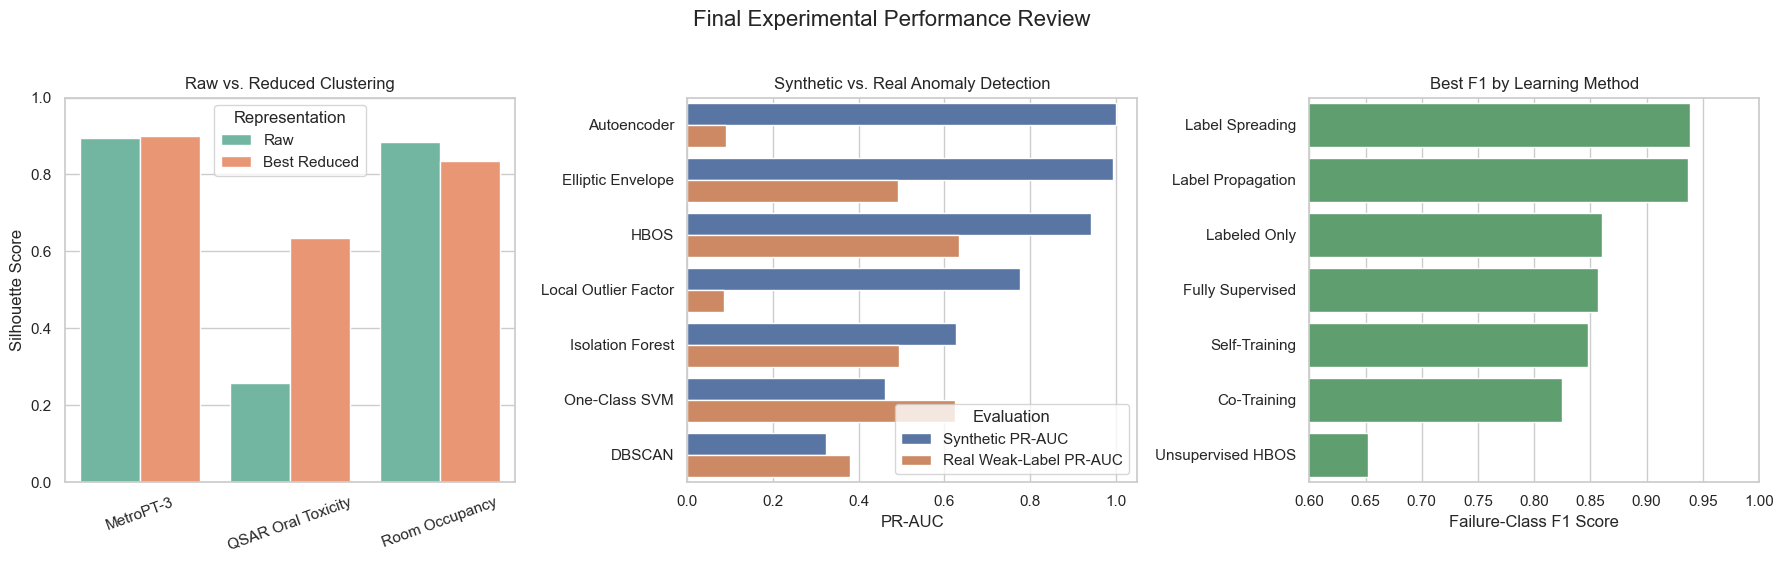

Best semi-supervised configuration per method:


,Method,Labeled_Fraction,Selected_Parameter,Accuracy,F1
11,Label Spreading,25%,neighbors=10,0.9925,0.9388
12,Label Propagation,25%,neighbors=10,0.9921,0.9365
13,Labeled Only,25%,—,0.9804,0.8605
16,Fully Supervised,100%,—,0.9796,0.8563
14,Self-Training,25%,threshold=0.95,0.9783,0.8480
15,Co-Training,25%,threshold=0.95,0.9742,0.8249
0,Unsupervised HBOS,0%,—,0.9608,0.6519


In [6]:
# Compare the principal findings from the previous notebooks.
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5)
)

# 1. Raw versus reduced clustering.
clustering_plot_df = (
    raw_vs_reduced_df[
        [
            "Dataset",
            "Raw_Silhouette",
            "Reduced_Silhouette"
        ]
    ]
    .melt(
        id_vars="Dataset",
        var_name="Representation",
        value_name="Silhouette"
    )
)

clustering_plot_df["Representation"] = (
    clustering_plot_df["Representation"]
    .replace({
        "Raw_Silhouette": "Raw",
        "Reduced_Silhouette": "Best Reduced"
    })
)

sns.barplot(
    data=clustering_plot_df,
    x="Dataset",
    y="Silhouette",
    hue="Representation",
    palette="Set2",
    ax=axes[0]
)

axes[0].set_title("Raw vs. Reduced Clustering")
axes[0].set_xlabel("")
axes[0].set_ylabel("Silhouette Score")
axes[0].tick_params(
    axis="x",
    rotation=20
)
axes[0].set_ylim(0, 1)

# 2. Synthetic-to-real anomaly transfer.
synthetic_pr_auc = (
    synthetic_anomaly_df[
        ["Algorithm", "PR_AUC"]
    ]
    .rename(
        columns={
            "PR_AUC": "Synthetic PR-AUC"
        }
    )
)

real_pr_auc = (
    weak_failure_anomaly_df[
        ["Algorithm", "PR_AUC"]
    ]
    .rename(
        columns={
            "PR_AUC": "Real Weak-Label PR-AUC"
        }
    )
)

anomaly_transfer_df = (
    synthetic_pr_auc
    .merge(
        real_pr_auc,
        on="Algorithm",
        how="inner"
    )
    .melt(
        id_vars="Algorithm",
        var_name="Evaluation",
        value_name="PR_AUC"
    )
)

sns.barplot(
    data=anomaly_transfer_df,
    x="PR_AUC",
    y="Algorithm",
    hue="Evaluation",
    palette=["#4C72B0", "#DD8452"],
    ax=axes[1]
)

axes[1].set_title("Synthetic vs. Real Anomaly Detection")
axes[1].set_xlabel("PR-AUC")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 1.05)

# 3. Best semi-supervised result per method.
best_semi_by_method_df = (
    semi_supervised_df
    .sort_values(
        ["F1", "Accuracy"],
        ascending=False
    )
    .groupby(
        "Method",
        as_index=False
    )
    .head(1)
    .sort_values(
        "F1",
        ascending=False
    )
)

sns.barplot(
    data=best_semi_by_method_df,
    x="F1",
    y="Method",
    color="#55A868",
    ax=axes[2]
)

axes[2].set_title("Best F1 by Learning Method")
axes[2].set_xlabel("Failure-Class F1 Score")
axes[2].set_ylabel("")
axes[2].set_xlim(0.60, 1.0)

fig.suptitle(
    "Final Experimental Performance Review",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

print("Best semi-supervised configuration per method:")
display(
    best_semi_by_method_df[
        [
            "Method",
            "Labeled_Fraction",
            "Selected_Parameter",
            "Accuracy",
            "F1"
        ]
    ].style.format({
        "Labeled_Fraction": "{:.0%}",
        "Accuracy": "{:.4f}",
        "F1": "{:.4f}"
    })
)

**Observation:** Dimensionality reduction produced the largest clustering improvement for QSAR Oral Toxicity, while its effect was small for MetroPT-3 and negative for Room Occupancy. The anomaly comparison reveals a major transfer gap: the Autoencoder performed perfectly on synthetic anomalies but poorly on real weak failure labels, whereas HBOS transferred much more reliably. Label Spreading and Label Propagation clearly outperformed the other learning methods.

### 5.5 Cluster Interpretation Through Feature Profiles

Cluster labels alone do not explain the discovered groups. To interpret them, each saved cluster assignment is linked back to its corresponding processed observation.

For every non-noise cluster, standardized mean differences are calculated relative to the complete evaluation sample. A positive value means that a feature is more prominent in that cluster, while a negative value indicates a lower-than-average value. The features with the largest absolute differences provide a concise description of each cluster.

In [14]:
# Reconstruct the exact samples used in Notebook 3.
dataset_configurations = [
    (
        "Room Occupancy",
        room_processed_df,
        room_clusters_df
    ),
    (
        "QSAR Oral Toxicity",
        qsar_processed_df,
        qsar_clusters_df
    ),
    (
        "MetroPT-3",
        metro_processed_df,
        metro_clusters_df
    )
]

pairwise_rng = np.random.default_rng(
    RANDOM_STATE
)

corrected_cluster_data = {}

for (
    dataset_name,
    processed_df,
    assignments_df
) in dataset_configurations:
    # Recreate the original 5,000-row pandas sample.
    experiment_indices = (
        processed_df
        .sample(
            n=5000,
            random_state=RANDOM_STATE
        )
        .index
        .to_numpy()
    )

    # Recreate the aligned 2,000-row pairwise sample.
    pairwise_positions = np.sort(
        pairwise_rng.choice(
            5000,
            size=2000,
            replace=False
        )
    )

    original_row_indices = (
        experiment_indices[
            pairwise_positions
        ]
    )

    sampled_rows = (
        processed_df
        .loc[original_row_indices]
        .reset_index(drop=True)
    )

    assignment_metadata = (
        assignments_df[
            [
                "Cluster_Label",
                "Is_Noise"
            ]
        ]
        .reset_index(drop=True)
    )

    corrected_cluster_data[
        dataset_name
    ] = pd.concat(
        [
            sampled_rows,
            assignment_metadata
        ],
        axis=1
    )

    print(f"\n{dataset_name}")
    print("Linked rows:", len(sampled_rows))
    print(
        "Cluster counts:",
        assignment_metadata[
            "Cluster_Label"
        ].value_counts().sort_index().to_dict()
    )

room_cluster_profile_df = (
    corrected_cluster_data[
        "Room Occupancy"
    ]
)

qsar_cluster_profile_df = (
    corrected_cluster_data[
        "QSAR Oral Toxicity"
    ]
)

metro_cluster_profile_df = (
    corrected_cluster_data[
        "MetroPT-3"
    ]
)


Room Occupancy
Linked rows: 2000
Cluster counts: {-1: 444, 0: 1359, 1: 197}

QSAR Oral Toxicity
Linked rows: 2000
Cluster counts: {-1: 310, 0: 1003, 1: 687}

MetroPT-3
Linked rows: 2000
Cluster counts: {0: 1766, 1: 124, 2: 110}


#### 5.5.1 Dominant Features and External-Label Composition

The dominant standardized feature deviations describe the sensor conditions or molecular fingerprints that distinguish each cluster. HDBSCAN noise observations are excluded from cluster profiles because they do not belong to a stable cluster.

For Room Occupancy and QSAR Oral Toxicity, the available labels are used only after clustering to examine cluster composition. They were not used to create the clusters.

In [15]:
# Identify the most distinctive features in every non-noise cluster.
def calculate_cluster_feature_profiles(
    clustered_df,
    excluded_columns,
    dataset_name,
    top_n=5
):
    feature_columns = [
        column
        for column in clustered_df.columns
        if (
            column not in excluded_columns
            and pd.api.types.is_numeric_dtype(
                clustered_df[column]
            )
        )
    ]

    overall_means = clustered_df[
        feature_columns
    ].mean()

    overall_standard_deviations = (
        clustered_df[
            feature_columns
        ]
        .std()
        .replace(0, np.nan)
    )

    profile_rows = []

    valid_clusters = sorted(
        clustered_df.loc[
            clustered_df["Cluster_Label"] != -1,
            "Cluster_Label"
        ].unique()
    )

    for cluster_label in valid_clusters:
        cluster_data = clustered_df[
            clustered_df["Cluster_Label"]
            == cluster_label
        ]

        standardized_differences = (
            (
                cluster_data[
                    feature_columns
                ].mean()
                - overall_means
            )
            / overall_standard_deviations
        ).dropna()

        dominant_features = (
            standardized_differences
            .abs()
            .sort_values(
                ascending=False
            )
            .head(top_n)
            .index
        )

        for feature_name in dominant_features:
            profile_rows.append({
                "Dataset": dataset_name,
                "Cluster": int(cluster_label),
                "Cluster_Size": len(cluster_data),
                "Feature": feature_name,
                "Standardized_Difference": (
                    standardized_differences[
                        feature_name
                    ]
                )
            })

    return pd.DataFrame(profile_rows)


room_feature_profiles_df = (
    calculate_cluster_feature_profiles(
        room_cluster_profile_df,
        excluded_columns=[
            "Room_Occupancy_Count",
            "Cluster_Label",
            "Is_Noise"
        ],
        dataset_name="Room Occupancy"
    )
)

qsar_feature_profiles_df = (
    calculate_cluster_feature_profiles(
        qsar_cluster_profile_df,
        excluded_columns=[
            "Toxicity_Class",
            "Cluster_Label",
            "Is_Noise"
        ],
        dataset_name="QSAR Oral Toxicity"
    )
)

metro_feature_profiles_df = (
    calculate_cluster_feature_profiles(
        metro_cluster_profile_df,
        excluded_columns=[
            "timestamp",
            "Window_Observation_Count",
            "Cluster_Label",
            "Is_Noise"
        ],
        dataset_name="MetroPT-3"
    )
)

for dataset_name, profile_df in {
    "Room Occupancy": room_feature_profiles_df,
    "QSAR Oral Toxicity": qsar_feature_profiles_df,
    "MetroPT-3": metro_feature_profiles_df
}.items():
    print(f"\nDominant features: {dataset_name}")

    display(
        profile_df.style.format({
            "Standardized_Difference": "{:+.3f}"
        }).background_gradient(
            subset=["Standardized_Difference"],
            cmap="coolwarm",
            vmin=-2,
            vmax=2
        )
    )

# Examine external-label composition without using labels for training.
room_label_composition = pd.crosstab(
    room_cluster_profile_df[
        "Cluster_Label"
    ],
    room_cluster_profile_df[
        "Room_Occupancy_Count"
    ],
    normalize="index"
)

qsar_label_composition = pd.crosstab(
    qsar_cluster_profile_df[
        "Cluster_Label"
    ],
    qsar_cluster_profile_df[
        "Toxicity_Class"
    ],
    normalize="index"
)

print("\nRoom Occupancy label composition:")
display(
    room_label_composition.style.format(
        "{:.1%}"
    )
)

print("\nQSAR toxicity label composition:")
display(
    qsar_label_composition.style.format(
        "{:.1%}"
    )
)


Dominant features: Room Occupancy


,Dataset,Cluster,Cluster_Size,Feature,Standardized_Difference
0,Room Occupancy,0,1359,S3_Temp,-0.521
1,Room Occupancy,0,1359,S5_CO2,-0.514
2,Room Occupancy,0,1359,S2_Temp,-0.472
3,Room Occupancy,0,1359,S1_Light,-0.462
4,Room Occupancy,0,1359,S4_Temp,-0.443
5,Room Occupancy,1,197,S5_CO2_Slope,-1.704
6,Room Occupancy,1,197,S5_CO2,+0.840
7,Room Occupancy,1,197,S3_Temp,+0.796
8,Room Occupancy,1,197,S4_Temp,+0.541
9,Room Occupancy,1,197,S2_Temp,+0.513



Dominant features: QSAR Oral Toxicity


,Dataset,Cluster,Cluster_Size,Feature,Standardized_Difference
0,QSAR Oral Toxicity,0,1003,Fingerprint_759,+0.731
1,QSAR Oral Toxicity,0,1003,Fingerprint_872,+0.730
2,QSAR Oral Toxicity,0,1003,Fingerprint_647,+0.728
3,QSAR Oral Toxicity,0,1003,Fingerprint_686,+0.727
4,QSAR Oral Toxicity,0,1003,Fingerprint_79,+0.726
5,QSAR Oral Toxicity,1,687,Fingerprint_647,-1.094
6,QSAR Oral Toxicity,1,687,Fingerprint_759,-1.082
7,QSAR Oral Toxicity,1,687,Fingerprint_872,-1.073
8,QSAR Oral Toxicity,1,687,Fingerprint_79,-1.069
9,QSAR Oral Toxicity,1,687,Fingerprint_686,-1.065



Dominant features: MetroPT-3


,Dataset,Cluster,Cluster_Size,Feature,Standardized_Difference
0,MetroPT-3,0,1766,DV_pressure_max,-0.287
1,MetroPT-3,0,1766,DV_pressure_std,-0.277
2,MetroPT-3,0,1766,TP2_mean,-0.249
3,MetroPT-3,0,1766,COMP_active_ratio,+0.245
4,MetroPT-3,0,1766,H1_mean,+0.243
5,MetroPT-3,1,124,DV_pressure_std,+3.461
6,MetroPT-3,1,124,DV_pressure_max,+3.327
7,MetroPT-3,1,124,TP2_std,+1.126
8,MetroPT-3,1,124,H1_std,+1.115
9,MetroPT-3,1,124,TP3_std,+0.988



Room Occupancy label composition:


Room_Occupancy_Count,0,1,2,3
Cluster_Label,,,,
-1,12.8%,22.3%,35.1%,29.7%
0,99.9%,0.0%,0.0%,0.1%
1,100.0%,0.0%,0.0%,0.0%



QSAR toxicity label composition:


Toxicity_Class,negative,positive
Cluster_Label,,
-1,77.1%,22.9%
0,94.4%,5.6%
1,92.0%,8.0%


**Observation:** Room Occupancy HDBSCAN separated two highly stable unoccupied groups, while most occupied observations were classified as noise. Cluster 0 represented a cooler, lower-CO2 and lower-light state. Cluster 1 showed higher temperature and CO2 but a strongly negative CO2 slope, which may represent a recently vacated or changing room. HDBSCAN therefore distinguished stable unoccupied states from more variable occupied conditions rather than separating every occupancy count.

QSAR clusters were distinguished by fingerprints 759, 872, 647, 686, and 79. However, both clusters remained dominated by the negative toxicity class. Positive compounds were concentrated more heavily among noise observations, explaining the relatively low external-label agreement.

MetroPT-3 produced three distinct operating regimes. Cluster 0 represented the dominant routine state. Cluster 1 showed unusually high discharge-valve pressure variation, while Cluster 2 combined higher TP2 and motor-current values with much lower H1 and compressor activity. These clusters describe operating modes and should not automatically be interpreted as faults.

### 5.6 Interpretation of HBOS Anomaly Decisions

HBOS calculates anomaly scores independently across feature histograms. Rare feature values receive larger anomaly contributions, making the method efficient and relatively transparent.

To interpret its final decisions, flagged and unflagged MetroPT-3 windows are compared using standardized mean differences. Spearman correlations are also calculated between every sensor feature and the continuous HBOS score. These complementary measures identify both features that distinguish flagged windows and features that change monotonically with anomaly severity.

Aligned MetroPT-3 windows: 24752
HBOS flagged windows: 1549

Largest flagged-versus-unflagged differences:


,Feature,Standardized_Flagged_Difference
26,Motor_current_min,+3.608
11,H1_max,-3.451
2,TP2_min,+3.447
28,COMP_active_ratio,-3.429
29,DV_eletric_active_ratio,+3.399
8,H1_mean,-3.381
31,MPG_active_ratio,-3.377
0,TP2_mean,+3.303
30,Towers_active_ratio,-3.272
12,DV_pressure_mean,+3.172



Strongest HBOS score correlations:


,Feature,Score_Correlation
31,MPG_active_ratio,-0.791
28,COMP_active_ratio,-0.786
30,Towers_active_ratio,-0.784
29,DV_eletric_active_ratio,+0.761
0,TP2_mean,+0.723
8,H1_mean,-0.674
24,Motor_current_mean,+0.648
10,H1_min,-0.606
27,Motor_current_max,+0.599
3,TP2_max,+0.577


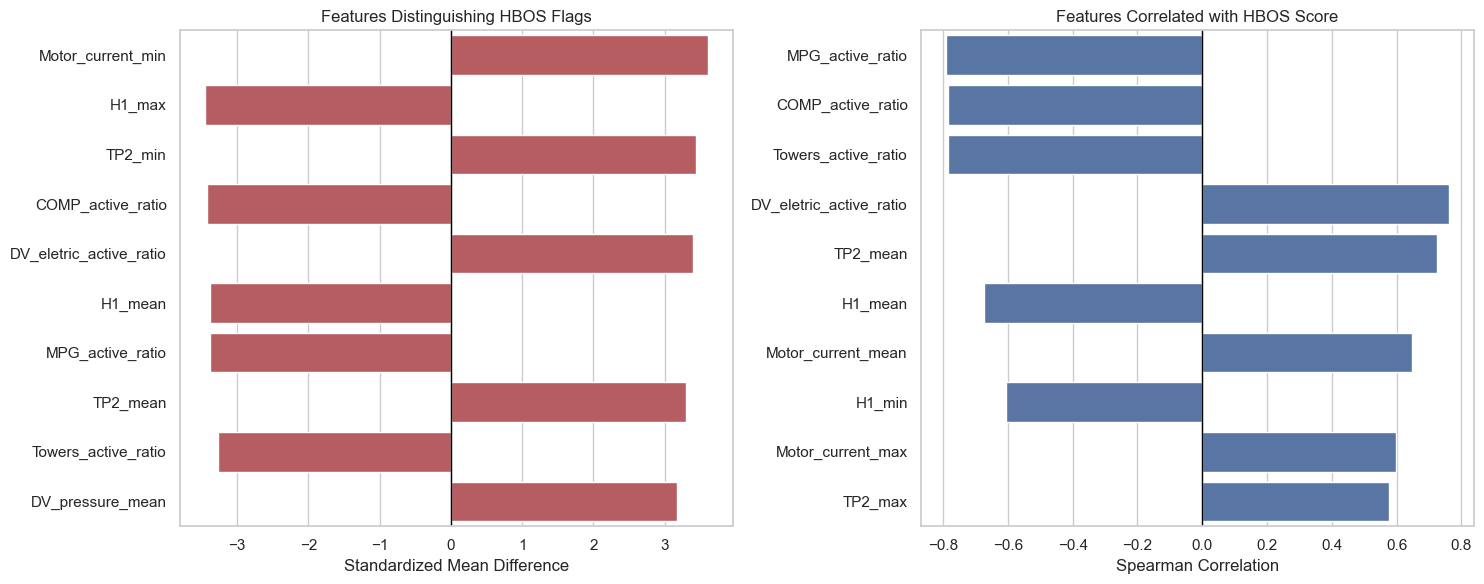

In [16]:
# Align final HBOS predictions with processed MetroPT-3 features.
metro_hbos_features_df = (
    metro_processed_df.copy()
)

metro_hbos_predictions_df = (
    hbos_full_predictions_df.copy()
)

metro_hbos_features_df["timestamp"] = (
    pd.to_datetime(
        metro_hbos_features_df["timestamp"]
    )
)

metro_hbos_predictions_df["timestamp"] = (
    pd.to_datetime(
        metro_hbos_predictions_df["timestamp"]
    )
)

metro_hbos_interpretation_df = (
    metro_hbos_predictions_df
    .merge(
        metro_hbos_features_df,
        on="timestamp",
        how="inner",
        validate="one_to_one"
    )
)

hbos_sensor_columns = [
    column
    for column in metro_processed_df.columns
    if (
        column not in [
            "timestamp",
            "Window_Observation_Count"
        ]
        and pd.api.types.is_numeric_dtype(
            metro_processed_df[column]
        )
    )
]

overall_standard_deviation = (
    metro_hbos_interpretation_df[
        hbos_sensor_columns
    ]
    .std()
    .replace(0, np.nan)
)

flagged_means = (
    metro_hbos_interpretation_df.loc[
        metro_hbos_interpretation_df[
            "HBOS_Anomaly_Flag"
        ] == 1,
        hbos_sensor_columns
    ].mean()
)

unflagged_means = (
    metro_hbos_interpretation_df.loc[
        metro_hbos_interpretation_df[
            "HBOS_Anomaly_Flag"
        ] == 0,
        hbos_sensor_columns
    ].mean()
)

hbos_feature_effects_df = pd.DataFrame({
    "Feature": hbos_sensor_columns,
    "Standardized_Flagged_Difference": (
        (
            flagged_means
            - unflagged_means
        )
        / overall_standard_deviation
    ).values
})

hbos_score_correlations = (
    metro_hbos_interpretation_df[
        hbos_sensor_columns
    ]
    .corrwith(
        metro_hbos_interpretation_df[
            "HBOS_Anomaly_Score"
        ],
        method="spearman"
    )
)

hbos_score_correlations_df = pd.DataFrame({
    "Feature": hbos_score_correlations.index,
    "Score_Correlation": (
        hbos_score_correlations.values
    )
})

top_hbos_effects_df = (
    hbos_feature_effects_df
    .assign(
        Absolute_Effect=lambda data:
        data[
            "Standardized_Flagged_Difference"
        ].abs()
    )
    .sort_values(
        "Absolute_Effect",
        ascending=False
    )
    .head(10)
)

top_hbos_correlations_df = (
    hbos_score_correlations_df
    .assign(
        Absolute_Correlation=lambda data:
        data["Score_Correlation"].abs()
    )
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .head(10)
)

print(
    "Aligned MetroPT-3 windows:",
    len(metro_hbos_interpretation_df)
)
print(
    "HBOS flagged windows:",
    int(
        metro_hbos_interpretation_df[
            "HBOS_Anomaly_Flag"
        ].sum()
    )
)

print("\nLargest flagged-versus-unflagged differences:")
display(
    top_hbos_effects_df[
        [
            "Feature",
            "Standardized_Flagged_Difference"
        ]
    ].style.format({
        "Standardized_Flagged_Difference":
            "{:+.3f}"
    })
)

print("\nStrongest HBOS score correlations:")
display(
    top_hbos_correlations_df[
        [
            "Feature",
            "Score_Correlation"
        ]
    ].style.format({
        "Score_Correlation": "{:+.3f}"
    })
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6)
)

sns.barplot(
    data=top_hbos_effects_df,
    x="Standardized_Flagged_Difference",
    y="Feature",
    color="#C44E52",
    ax=axes[0]
)

axes[0].axvline(
    0,
    color="black",
    linewidth=1
)
axes[0].set_title(
    "Features Distinguishing HBOS Flags"
)
axes[0].set_xlabel(
    "Standardized Mean Difference"
)
axes[0].set_ylabel("")

sns.barplot(
    data=top_hbos_correlations_df,
    x="Score_Correlation",
    y="Feature",
    color="#4C72B0",
    ax=axes[1]
)

axes[1].axvline(
    0,
    color="black",
    linewidth=1
)
axes[1].set_title(
    "Features Correlated with HBOS Score"
)
axes[1].set_xlabel(
    "Spearman Correlation"
)
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Observation:** HBOS flagged 1,549 of 24,752 complete MetroPT-3 windows. Flagged windows were characterized by substantially higher minimum motor current, TP2 pressure, and electrical-valve activity, together with lower H1 pressure and compressor activity. The anomaly score was most strongly associated with reduced MPG, compressor, and tower activity and increased electrical-valve activity. These patterns suggest that HBOS primarily identifies unusual compressor operating-state transitions rather than responding to a single sensor alone.

### 5.7 Interpretation of Label Spreading Predictions

Label Spreading is a graph-based, non-parametric method and therefore does not provide coefficients or built-in feature importance. Its behaviour is interpreted through error analysis.

The saved test predictions are aligned with MetroPT-3 sensor windows. True positives, false negatives, false positives, and true negatives are identified, after which the sensor profiles of correctly and incorrectly classified failure windows are compared. This reveals the conditions under which the selected model succeeds or fails.

Aligned Label Spreading test windows: 2400

Prediction outcomes:


,Window_Count
Prediction_Outcome,
True Positive,138
False Negative,10
False Positive,8
True Negative,2244



Features distinguishing missed from detected failures:


,Feature,Missed_Minus_Detected_Failures
7,TP3_max,+0.709
19,Reservoirs_max,+0.709
11,H1_max,+0.699
12,DV_pressure_mean,-0.592
4,TP3_mean,+0.582
16,Reservoirs_mean,+0.580
2,TP2_min,-0.542
8,H1_mean,+0.514
29,DV_eletric_active_ratio,-0.508
17,Reservoirs_std,+0.508


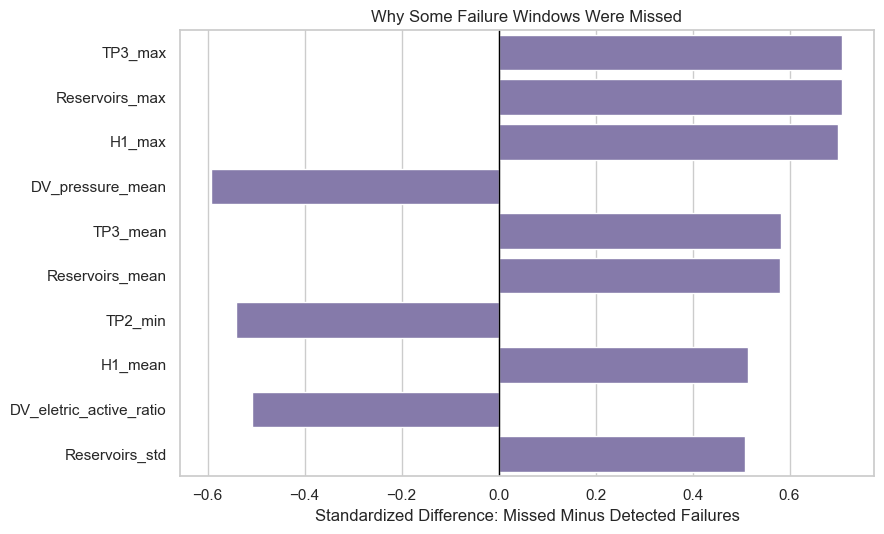

In [17]:
# Align Label Spreading predictions with MetroPT-3 features.
label_spreading_predictions_df[
    "timestamp"
] = pd.to_datetime(
    label_spreading_predictions_df[
        "timestamp"
    ]
)

label_spreading_interpretation_df = (
    label_spreading_predictions_df
    .merge(
        metro_hbos_features_df,
        on="timestamp",
        how="inner",
        validate="one_to_one"
    )
)

actual_labels = (
    label_spreading_interpretation_df[
        "Weak_Failure_Label"
    ]
)

predicted_labels = (
    label_spreading_interpretation_df[
        "Label_Spreading_Prediction"
    ]
)

label_spreading_interpretation_df[
    "Prediction_Outcome"
] = np.select(
    [
        (actual_labels == 1)
        & (predicted_labels == 1),

        (actual_labels == 1)
        & (predicted_labels == 0),

        (actual_labels == 0)
        & (predicted_labels == 1),

        (actual_labels == 0)
        & (predicted_labels == 0)
    ],
    [
        "True Positive",
        "False Negative",
        "False Positive",
        "True Negative"
    ],
    default="Unknown"
)

outcome_order = [
    "True Positive",
    "False Negative",
    "False Positive",
    "True Negative"
]

outcome_counts = (
    label_spreading_interpretation_df[
        "Prediction_Outcome"
    ]
    .value_counts()
    .reindex(
        outcome_order,
        fill_value=0
    )
)

print(
    "Aligned Label Spreading test windows:",
    len(label_spreading_interpretation_df)
)

print("\nPrediction outcomes:")
display(
    outcome_counts.rename(
        "Window_Count"
    ).to_frame()
)

# Compare missed failures with correctly detected failures.
test_feature_standard_deviations = (
    label_spreading_interpretation_df[
        hbos_sensor_columns
    ]
    .std()
    .replace(0, np.nan)
)

true_positive_means = (
    label_spreading_interpretation_df.loc[
        label_spreading_interpretation_df[
            "Prediction_Outcome"
        ] == "True Positive",
        hbos_sensor_columns
    ].mean()
)

false_negative_means = (
    label_spreading_interpretation_df.loc[
        label_spreading_interpretation_df[
            "Prediction_Outcome"
        ] == "False Negative",
        hbos_sensor_columns
    ].mean()
)

failure_error_profiles_df = pd.DataFrame({
    "Feature": hbos_sensor_columns,
    "Missed_Minus_Detected_Failures": (
        (
            false_negative_means
            - true_positive_means
        )
        / test_feature_standard_deviations
    ).values
})

top_failure_error_profiles_df = (
    failure_error_profiles_df
    .assign(
        Absolute_Difference=lambda data:
        data[
            "Missed_Minus_Detected_Failures"
        ].abs()
    )
    .sort_values(
        "Absolute_Difference",
        ascending=False
    )
    .head(10)
)

print(
    "\nFeatures distinguishing missed "
    "from detected failures:"
)

display(
    top_failure_error_profiles_df[
        [
            "Feature",
            "Missed_Minus_Detected_Failures"
        ]
    ].style.format({
        "Missed_Minus_Detected_Failures":
            "{:+.3f}"
    })
)

plt.figure(figsize=(9, 5.5))

sns.barplot(
    data=top_failure_error_profiles_df,
    x="Missed_Minus_Detected_Failures",
    y="Feature",
    color="#8172B2"
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Why Some Failure Windows Were Missed"
)
plt.xlabel(
    "Standardized Difference: "
    "Missed Minus Detected Failures"
)
plt.ylabel("")
plt.tight_layout()
plt.show()


**Observation:** Label Spreading correctly detected 138 of 148 failure windows and generated only eight false-positive alerts. The ten missed failures had higher TP3, reservoir, and H1 pressure values but lower discharge-valve pressure, TP2 minimum pressure, and electrical-valve activity than detected failures. These windows therefore differed from the local failure patterns learned by the graph. However, this comparison is based on only ten false negatives, so the feature differences should be treated as diagnostic evidence rather than universal failure rules.

### 5.8 Final Model Selection and Practical Trade-Offs

Model selection must consider performance, computational cost, interpretability, and the purpose of each dataset. Metrics from different tasks are not directly interchangeable; therefore, the final models are selected separately for clustering, anomaly detection, and semi-supervised failure classification.

For anomaly detection, real weak-label PR-AUC is plotted against scoring time. This highlights whether improved detection requires substantially greater computational cost.

,Task,Selected_Model,Primary_Result,Reason_for_Selection,Main_Limitation
0,Clustering: MetroPT-3,PCA + K-Medoids,Silhouette = 0.9011,Best valid internal clustering solution for th...,Cluster meaning requires domain validation
1,Clustering: QSAR Oral Toxicity,UMAP + HDBSCAN,Silhouette = 0.6351,Best valid internal clustering solution for th...,Noise fraction = 15.5%
2,Clustering: Room Occupancy,Raw Scaled + HDBSCAN,Silhouette = 0.8833,Best valid internal clustering solution for th...,Noise fraction = 22.2%
3,Real weak-label anomaly detection,HBOS,PR-AUC = 0.6342,Best real-failure PR-AUC with very low scoring...,Independent histograms do not model feature in...
4,Semi-supervised failure classification,Label Spreading (neighbors=10),F1 = 0.9388,Best failure-class F1 using only 25% labeled t...,Graph construction can become expensive on muc...


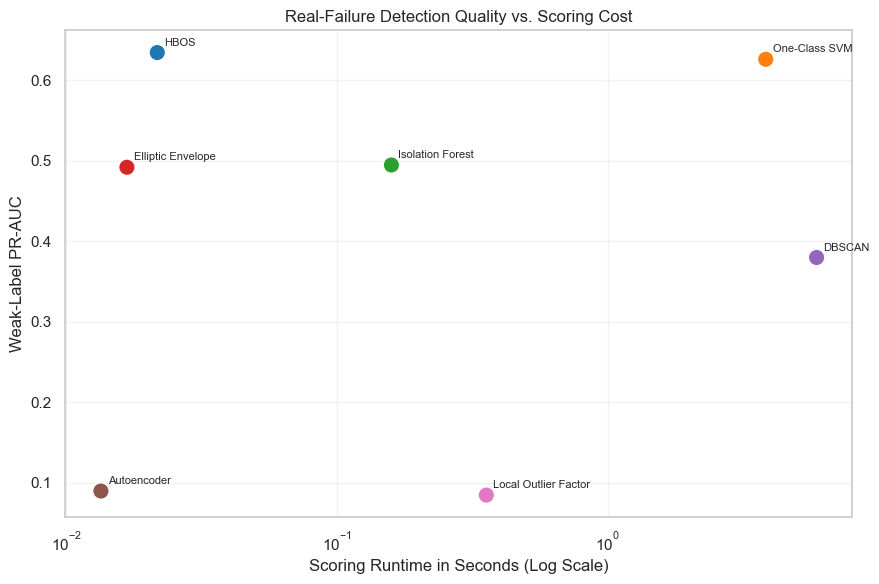

In [19]:
# Summarize the final selections across all project tasks.
final_selection_rows = []

for _, row in best_clustering_df.iterrows():
    final_selection_rows.append({
        "Task": (
            f"Clustering: {row['Dataset']}"
        ),
        "Selected_Model": (
            f"{row['Representation']} + "
            f"{row['Algorithm']}"
        ),
        "Primary_Result": (
            f"Silhouette = "
            f"{row['Silhouette']:.4f}"
        ),
        "Reason_for_Selection": (
            "Best valid internal clustering "
            "solution for this dataset"
        ),
        "Main_Limitation": (
            f"Noise fraction = "
            f"{row['Noise_Fraction']:.1%}"
            if row["Noise_Fraction"] > 0
            else (
                "Cluster meaning requires "
                "domain validation"
            )
        )
    })

best_real_anomaly_row = (
    weak_failure_anomaly_df
    .sort_values(
        [
            "PR_AUC",
            "Precision_at_k"
        ],
        ascending=False
    )
    .iloc[0]
)

final_selection_rows.append({
    "Task": (
        "Real weak-label anomaly detection"
    ),
    "Selected_Model": (
        best_real_anomaly_row["Algorithm"]
    ),
    "Primary_Result": (
        f"PR-AUC = "
        f"{best_real_anomaly_row['PR_AUC']:.4f}"
    ),
    "Reason_for_Selection": (
        "Best real-failure PR-AUC with "
        "very low scoring cost"
    ),
    "Main_Limitation": (
        "Independent histograms do not model "
        "feature interactions directly"
    )
})

best_semi_row = (
    semi_supervised_df
    .sort_values(
        [
            "F1",
            "Accuracy"
        ],
        ascending=False
    )
    .iloc[0]
)

final_selection_rows.append({
    "Task": (
        "Semi-supervised failure classification"
    ),
    "Selected_Model": (
        f"{best_semi_row['Method']} "
        f"({best_semi_row['Selected_Parameter']})"
    ),
    "Primary_Result": (
        f"F1 = {best_semi_row['F1']:.4f}"
    ),
    "Reason_for_Selection": (
        "Best failure-class F1 using only "
        "25% labeled training data"
    ),
    "Main_Limitation": (
        "Graph construction can become expensive "
        "on much larger datasets"
    )
})

final_model_selection_df = pd.DataFrame(
    final_selection_rows
)

display(final_model_selection_df)

# Compare anomaly-detection quality with scoring cost.
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=weak_failure_anomaly_df,
    x="Scoring_Runtime",
    y="PR_AUC",
    hue="Algorithm",
    s=140,
    palette="tab10",
    legend=False
)

for _, row in (
    weak_failure_anomaly_df.iterrows()
):
    plt.annotate(
        row["Algorithm"],
        (
            row["Scoring_Runtime"],
            row["PR_AUC"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

plt.xscale("log")

plt.title(
    "Real-Failure Detection Quality "
    "vs. Scoring Cost"
)

plt.xlabel(
    "Scoring Runtime in Seconds "
    "(Log Scale)"
)

plt.ylabel(
    "Weak-Label PR-AUC"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()
plt.show()

**Observation:** HBOS provided the strongest practical anomaly-detection trade-off, achieving the highest real weak-label PR-AUC while requiring only 0.0217 seconds for scoring. One-Class SVM produced a similar PR-AUC but required several seconds, while the faster Autoencoder transferred poorly from synthetic anomalies to real failure intervals. Final model selection therefore depended on the target dataset, representation, evaluation evidence, and operational cost rather than on a single universal algorithm.

### 5.9 Saving Interpretation and Final Comparison Results

The cluster profiles, HBOS interpretation measures, Label Spreading error profiles, and final model-selection table are saved for use in the project report and presentation.

In [20]:
# Save all Notebook 5 interpretation outputs.
notebook_5_outputs = {
    "room_occupancy_cluster_feature_profiles.csv":
        room_feature_profiles_df,

    "qsar_cluster_feature_profiles.csv":
        qsar_feature_profiles_df,

    "metropt3_cluster_feature_profiles.csv":
        metro_feature_profiles_df,

    "hbos_flagged_feature_differences.csv":
        hbos_feature_effects_df,

    "hbos_score_feature_correlations.csv":
        hbos_score_correlations_df,

    "label_spreading_failure_error_profiles.csv":
        failure_error_profiles_df,

    "final_model_selection.csv":
        final_model_selection_df
}

prediction_outcomes_df = (
    outcome_counts
    .rename("Window_Count")
    .reset_index()
)

prediction_outcomes_df.columns = [
    "Prediction_Outcome",
    "Window_Count"
]

notebook_5_outputs[
    "label_spreading_prediction_outcomes.csv"
] = prediction_outcomes_df

for filename, output_df in (
    notebook_5_outputs.items()
):
    output_path = (
        RESULTS_DIR
        / filename
    )

    output_df.to_csv(
        output_path,
        index=False
    )

    print(
        f"Saved: {filename} "
        f"| Shape: {output_df.shape}"
    )

print(
    "\nNotebook 5 interpretation files saved:",
    len(notebook_5_outputs)
)

Saved: room_occupancy_cluster_feature_profiles.csv | Shape: (10, 5)
Saved: qsar_cluster_feature_profiles.csv | Shape: (10, 5)
Saved: metropt3_cluster_feature_profiles.csv | Shape: (15, 5)
Saved: hbos_flagged_feature_differences.csv | Shape: (36, 2)
Saved: hbos_score_feature_correlations.csv | Shape: (36, 2)
Saved: label_spreading_failure_error_profiles.csv | Shape: (36, 2)
Saved: final_model_selection.csv | Shape: (5, 5)
Saved: label_spreading_prediction_outcomes.csv | Shape: (4, 2)

Notebook 5 interpretation files saved: 8


### 5.10 Limitations and Responsible Interpretation

Several limitations must be considered when interpreting the results.

First, expensive clustering algorithms were evaluated on fixed samples of 2,000 observations drawn from the 5,000-row experimental samples. This made broad algorithm comparison computationally feasible, but the selected solutions may change when fitted to the complete datasets.

Second, internal clustering metrics measure geometric separation rather than real-world usefulness. HDBSCAN achieved strong Silhouette Scores partly by treating difficult observations as noise. For Room Occupancy, most occupied observations were classified as noise, demonstrating that high internal separation does not necessarily mean complete recovery of the available labels.

Third, nonlinear dimensionality-reduction methods such as UMAP and t-SNE prioritize local neighbourhood structure and can vary across random seeds or parameter choices. Their reduced coordinates should therefore be interpreted as representations of local similarity rather than exact physical measurements.

Fourth, MetroPT-3 failure labels were constructed from incomplete maintenance intervals. Unreported anomalies may exist outside these intervals, while some labeled windows may represent normal recovery or transition behaviour. The reported anomaly and semi-supervised metrics consequently measure agreement with available weak labels rather than complete knowledge of equipment condition.

Fifth, synthetic anomaly performance depended on the chosen injection mechanisms. The Autoencoder’s perfect synthetic result did not transfer to real failure intervals, showing that artificial benchmarks may favour models that recognize the injection design rather than genuine equipment anomalies.

Finally, feature profiles, score correlations, and error comparisons describe associations rather than causal relationships. The Label Spreading error profile was based on only ten missed failures, and all computational runtimes depend on the available hardware and software environment.

### 5.11 Conclusion

This notebook completed the interpretation and final comparison of the project’s clustering, dimensionality-reduction, anomaly-detection, and semi-supervised learning pipelines.

The clustering experiments showed that representation choice must be dataset-specific. PCA slightly improved MetroPT-3 clustering, producing a Silhouette Score of 0.9011 with K-Medoids. UMAP substantially improved QSAR Oral Toxicity clustering, where HDBSCAN achieved a Silhouette Score of 0.6351. Room Occupancy performed best in the raw scaled feature space, where HDBSCAN achieved a Silhouette Score of 0.8833.

Cluster profiling revealed that the models identified meaningful operating patterns, but these patterns did not always correspond directly to available labels. Room Occupancy clusters primarily represented stable unoccupied environmental states, while variable occupied observations were frequently classified as noise. QSAR clusters were separated by specific molecular fingerprints but showed limited toxicity-class separation. MetroPT-3 clusters represented distinct compressor operating regimes involving pressure, motor current, and equipment activity.

Anomaly-detection interpretation confirmed that synthetic benchmark performance was not a reliable indicator of real-failure performance. Although the Autoencoder perfectly detected the injected anomalies, HBOS achieved the strongest real weak-label results with PR-AUC = 0.6342 and Precision@k = 0.6775. It also required only 0.0217 seconds for scoring, making it the strongest practical anomaly detector.

The semi-supervised comparison selected Label Spreading with 25% labeled data and 10 neighbours. It achieved Accuracy = 0.9925 and F1 = 0.9388, correctly detecting 138 of 148 failure windows with only eight false-positive alerts. Its performance demonstrated that local sensor neighbourhoods contained useful information for propagating limited weak labels.

Overall, no single algorithm was best for every task. The strongest solutions resulted from matching the model and representation to the dataset structure, evaluating rare-event performance carefully, checking computational cost, and interpreting model outputs alongside their limitations. All final comparison and interpretation outputs were saved for the project report and presentation.